# Проект по дисциплине "Неройнные сети"
## Задача: классификация породы котов на датасете "pop-cats"

## Импорт библиотек и настройка среды

- импорт PyTorch и torchvision;
- настройка отрисовки графиков;
- фиксация seed;
- определение устройства (`cpu` или `cuda`).


In [61]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset

from torchvision import transforms, models

MY_SEED = 42

torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)
random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 42


## Загрузка датасета из kaggle

In [62]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("knucharat/pop-cats", output_dir="./cats20")

In [63]:
dataset_path = "./cats20/cats20"  #"/kaggle/input/pop-cats/cats20"

print("Path to dataset files:", dataset_path)

Path to dataset files: ./cats20/cats20


Трансформации

In [64]:
IMG_SIZE = 256

train_transform = transforms.Compose([
    transforms.RandomResizedCrop((IMG_SIZE, IMG_SIZE), scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=([0.5374, 0.5021, 0.4675]),
        std=[0.2222, 0.2228, 0.2262]
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((int(IMG_SIZE * 1.15), int(IMG_SIZE * 1.15))),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=([0.5374, 0.5021, 0.4675]),
        std=[0.2222, 0.2228, 0.2262]
    )
])

print("Трансформации определены.")

Трансформации определены.


In [65]:
from torchvision import datasets
from PIL import Image

def is_valid_image(filepath):
  try:
    with Image.open(filepath) as img:
      img.verify()
    return True
  except Exception:
    return False

full_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transform, is_valid_file=is_valid_image )
preview_dataset = datasets.ImageFolder(root=dataset_path, is_valid_file=is_valid_image)
classes = full_dataset.classes
print("Количество классов:", len(classes))
print("Размер dataset:", len(full_dataset))

Количество классов: 20
Размер dataset: 9999


вывод изображений каждого класса

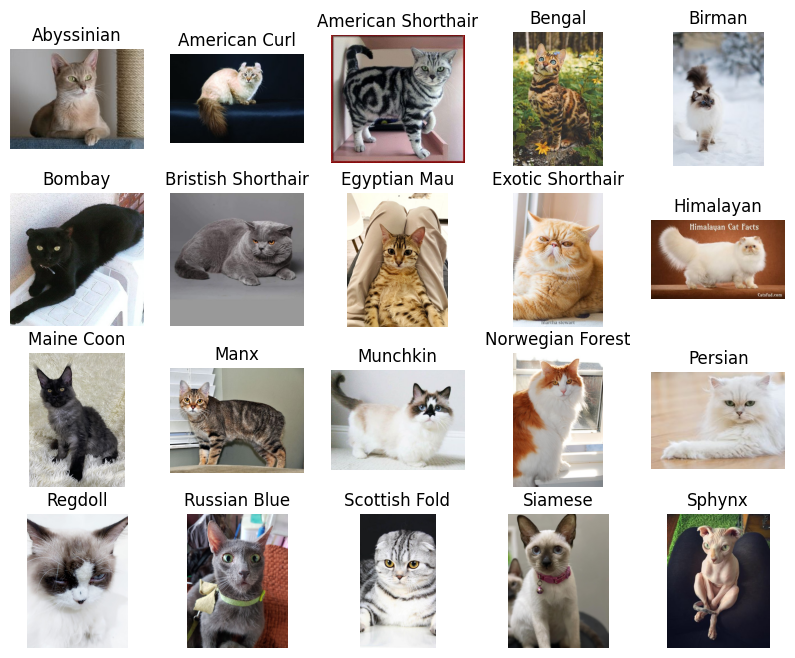

In [66]:
class_to_idx = {}
for idx, (_, label) in enumerate(preview_dataset.samples):
    if label not in class_to_idx:
        class_to_idx[label] = idx

num_classes = len(classes)

plt.figure(figsize=(10, 8))

for i, cls_id in enumerate(range(num_classes)):
    img_idx = class_to_idx[cls_id]
    img, label = preview_dataset[img_idx]
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.title(classes[label])
    plt.axis("off")

plt.show()

Создание train/val/test

In [67]:
# Отдельные datasets для train и val/test
train_full_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform,
    is_valid_file=is_valid_image
)

test_full_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=test_transform,
    is_valid_file=is_valid_image
)

dataset_size = len(train_full_dataset)

train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

# Общие индексы
indices = list(range(dataset_size))

random.seed(MY_SEED)
random.shuffle(indices)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

# Создание subset
train_dataset = Subset(train_full_dataset, train_idx)

val_dataset = Subset(test_full_dataset, val_idx)

test_dataset = Subset(test_full_dataset, test_idx)

## Конфигурация

In [68]:
BATCH_SIZE = 64
learning_rate = 3e-5

In [69]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [70]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

def denorm(img_tensor):
    img = img_tensor.permute(1, 2, 0).numpy()
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

In [71]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if self.best_loss is None or val_loss < (self.best_loss - self.min_delta):
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            return False
        else:
            self.counter += 1

            if self.counter >= self.patience:
                return True

            return False

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

print("Класс EarlyStopping определён.")

Класс EarlyStopping определён.


In [72]:
base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in base_model.parameters():
    param.requires_grad = True

num_ftrs = base_model.fc.in_features
num_target_classes = len(full_dataset.classes)

base_model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_target_classes)
)

model_tl = base_model.to(device)
print(model_tl.fc)

Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=20, bias=True)
)


In [73]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model_tl.parameters(),
    lr=learning_rate,
    weight_decay=3e-4
)

print("Функция потерь:", criterion)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
learning_rate = 3e-05


In [74]:
def train_one_epoch(model_tl, dataloader, optimizer, criterion, device):
    model_tl.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_tl(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, total_correct / total

def evaluate(model_tl, dataloader, criterion, device):
    model_tl.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model_tl(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [75]:
early_stopper = EarlyStopping(patience=5, min_delta=0.0)

num_epochs = 20

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model_tl,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc = evaluate(
        model_tl,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Эпоха {epoch}/{num_epochs}: "
        f"train_loss={train_loss:.4f}, "
        f"train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, "
        f"val_acc={val_acc:.4f}"
    )

    if early_stopper.step(val_loss, model_tl):
        print("Ранняя остановка!")
        break

# восстановить лучшую модель
early_stopper.restore_best(model_tl)

print("Обучение завершено.")

Эпоха 1/20: train_loss=2.5569, train_acc=0.3035, val_loss=1.9339, val_acc=0.5490
Эпоха 2/20: train_loss=1.6754, train_acc=0.5795, val_loss=1.3040, val_acc=0.6731
Эпоха 3/20: train_loss=1.1722, train_acc=0.7047, val_loss=0.8964, val_acc=0.7912
Эпоха 4/20: train_loss=0.7996, train_acc=0.8104, val_loss=0.6542, val_acc=0.8459
Эпоха 5/20: train_loss=0.5669, train_acc=0.8660, val_loss=0.5345, val_acc=0.8652
Эпоха 6/20: train_loss=0.4311, train_acc=0.9007, val_loss=0.4758, val_acc=0.8759
Эпоха 7/20: train_loss=0.3278, train_acc=0.9298, val_loss=0.4186, val_acc=0.8826
Эпоха 8/20: train_loss=0.2543, train_acc=0.9456, val_loss=0.3870, val_acc=0.8899
Эпоха 9/20: train_loss=0.2026, train_acc=0.9563, val_loss=0.3912, val_acc=0.8853
Эпоха 10/20: train_loss=0.1666, train_acc=0.9631, val_loss=0.3783, val_acc=0.8959
Эпоха 11/20: train_loss=0.1297, train_acc=0.9744, val_loss=0.3730, val_acc=0.8939
Эпоха 12/20: train_loss=0.0995, train_acc=0.9827, val_loss=0.3788, val_acc=0.8926
Эпоха 13/20: train_loss=0

In [76]:
test_loss, test_acc = evaluate(model_tl, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.3503
Test Accuracy: 0.8954


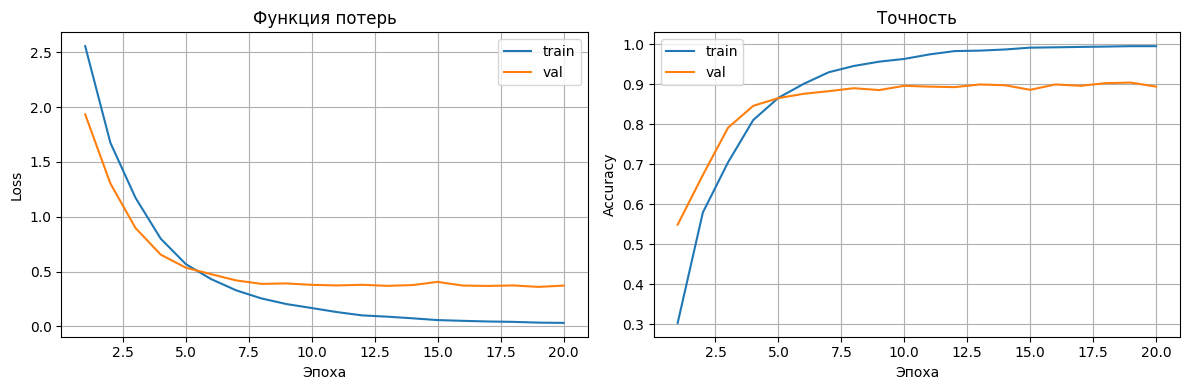

Финальная точность: train=0.9950, val=0.8939


In [77]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)

plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")

plt.xlabel("Эпоха")
plt.ylabel("Loss")

plt.title("Функция потерь")

plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")

plt.xlabel("Эпоха")
plt.ylabel("Accuracy")

plt.title("Точность")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(
    f"Финальная точность: "
    f"train={history['train_acc'][-1]:.4f}, "
    f"val={history['val_acc'][-1]:.4f}"
)

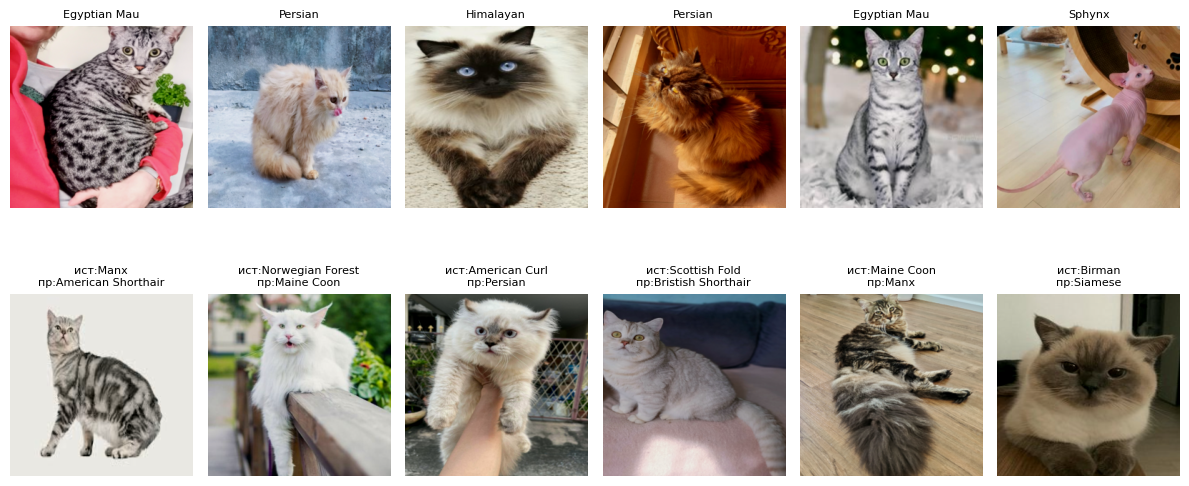

In [78]:
model_tl.eval()
correct_imgs, correct_true, correct_pred = [], [], []
wrong_imgs, wrong_true, wrong_pred = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_tl(images)
        preds = outputs.argmax(dim=1)

        for img, lab, pr in zip(images, labels, preds):
            if lab == pr and len(correct_imgs) < 6:
                correct_imgs.append(img.cpu())
                correct_true.append(lab.cpu().item())
                correct_pred.append(pr.cpu().item())
            if lab != pr and len(wrong_imgs) < 6:
                wrong_imgs.append(img.cpu())
                wrong_true.append(lab.cpu().item())
                wrong_pred.append(pr.cpu().item())
        if len(correct_imgs) >= 6 and len(wrong_imgs) >= 6:
            break

plt.figure(figsize=(12, 6))
for i in range(len(correct_imgs)):
    plt.subplot(2, 6, i + 1)
    plt.imshow(denorm(correct_imgs[i]))
    plt.title(classes[correct_true[i]], fontsize=8)
    plt.axis("off")
for i in range(len(wrong_imgs)):
    plt.subplot(2, 6, 6 + i + 1)
    plt.imshow(denorm(wrong_imgs[i]))
    true_label = classes[wrong_true[i]]
    pred_label = classes[wrong_pred[i]]
    plt.title(f"ист:{true_label}\nпр:{pred_label}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()